In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import transpile
from qiskit.circuit import Gate
from qiskit.circuit.library import PhaseGate, UnitaryGate
from qiskit.quantum_info import random_unitary
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
SEED = 1234
backend = AerSimulator(seed_simulator=SEED)
sampler = Sampler(backend)

# Phase estimation and Quantum Fourier Transform

> ### Phase estimation problem
> **Input:**  
> * A unitary quantum circuit implementing an $n$-qubit operation $U$, together with an $n$-qubit eigenstate $|\psi\rangle$ of $U$
>
> **Output:**  
> * An approximation to the number $\theta \in [0,1)$ satisfying $U|\psi\rangle=e^{2\pi i\theta}|\psi\rangle$

In order to solve this problem, it is essential to introduce the Quantum Fourier Transform (QFT). Its $N$-dimensional expression can be described by an $N \times N$ matrix whose rows and columns are associated with the standard computational basis:

$$
QFT_N = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} \sum_{y=0}^{N-1} \omega_N^{xy} |y\rangle \langle x|
$$

where:

$$
\omega_N = e^{2\pi i/N}
$$

Equivalently, the action of the QFT on a computational basis state is:

$$
QFT_N |x\rangle = \frac{1}{\sqrt{N}} \sum_{y=0}^{N-1} \omega_N^{xy} |y\rangle
$$

We can check that the QFT is unitary and therefore invertible, so its inverse is given by:

$$
QFT_N^\dagger = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} \sum_{y=0}^{N-1} \omega_N^{-xy} |y\rangle \langle x|
$$

The QFT can be built iteratively. For each qubit $j$, we apply a Hadamard gate and then controlled phase rotations with the qubits that come after it. The farther away the control qubit is, the smaller the rotation angle becomes. In general, the controlled phase angle between qubits $j$ and $k$ is:

$$
\theta = \frac{\pi}{2^{k-j}}
$$

After applying these operations to all qubits, the output order is reversed, so SWAP gates are usually added at the end to obtain the standard qubit ordering.

In [3]:
def qft(nqbits: int) -> QuantumCircuit:
    """
    Builds the Quantum Fourier Transform given the number of qbits
    """
    qc = QuantumCircuit(nqbits)
    for i in range(nqbits):
        qc.h(i)
        for j in range(nqbits - i - 1):
            qc.cp(np.pi/2**(j+1), i, i+j+1)
        # qc.barrier()
    for i in range(int(nqbits/2)):
        qc.swap(i, nqbits-i-1)

    return qc

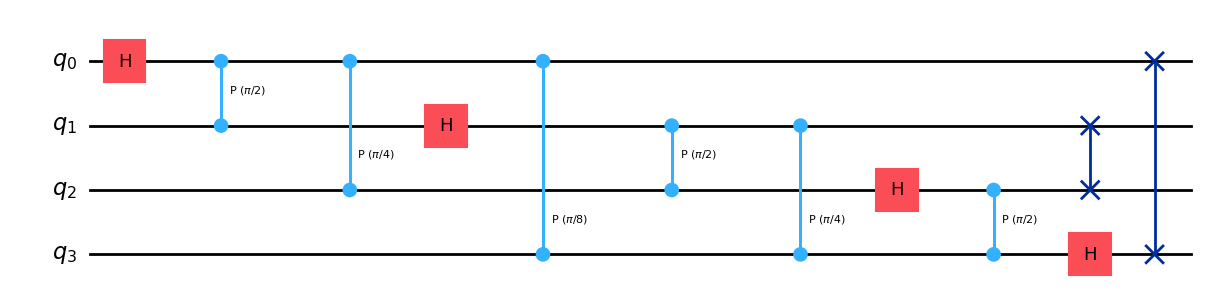

In [4]:
qc = qft(4)
qc.draw("mpl")

In [5]:
def iqft(nqbits: int) -> QuantumCircuit:
    """
    Builds the Inverse Quantum Fourier Transform given the number of qbits
    """
    qc = QuantumCircuit(nqbits)
    for i in range(int(nqbits/2)):
        qc.swap(i, nqbits-i-1)
    for i in reversed(range(nqbits)):
        for j in reversed(range(nqbits - i - 1)):
            qc.cp(-np.pi/2**(j+1), i, i+j+1)
        qc.h(i)
        # qc.barrier()

    return qc

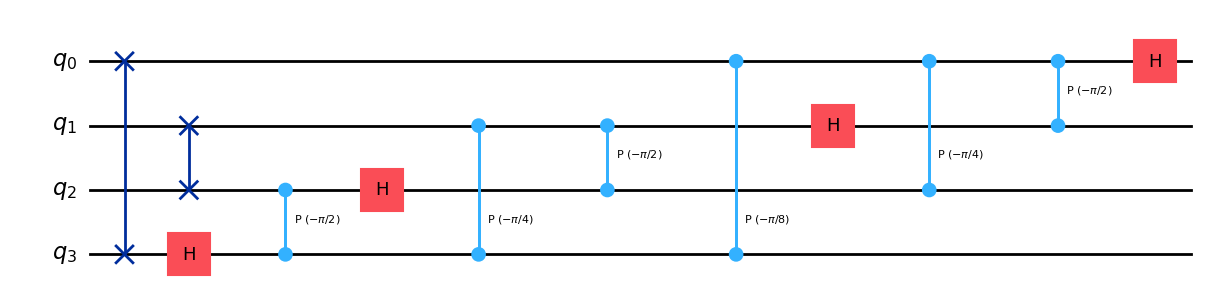

In [6]:
qc = iqft(4)
qc.draw("mpl")

We are now ready to implement the Phase Estimation Algorithm. The algorithm uses two registers. The first one is the counting register, initialized in $|0\rangle^{\otimes m}$, and the second one stores an eigenstate $|\psi\rangle$ of a unitary operator $U$.

The key assumption is that $|\psi\rangle$ is an eigenstate of $U$, so applying $U$ to it only adds a phase:

$$
U|\psi\rangle = e^{2\pi i \theta}|\psi\rangle
$$

where $\theta \in [0,1)$ is the phase we want to estimate.

First, we apply Hadamard gates to the counting register. This transforms the initial state

$$
|0\rangle^{\otimes m}|\psi\rangle
$$

into a uniform superposition:

$$
\frac{1}{\sqrt{2^m}}\sum_{j=0}^{2^m-1}|j\rangle|\psi\rangle
$$

Then, we apply controlled powers of the unitary operator:

$$
CU^{2^0}, CU^{2^1}, CU^{2^2}, \ldots, CU^{2^{m-1}}
$$

These gates are used because each basis state $|j\rangle$ in the counting register controls a different power of $U$. Since $|\psi\rangle$ is an eigenstate, applying $U^j$ to it gives:

$$
U^j|\psi\rangle = e^{2\pi i j\theta}|\psi\rangle
$$

Therefore, after the controlled-unitary operations, the global state becomes:

$$
\frac{1}{\sqrt{2^m}}\sum_{j=0}^{2^m-1} e^{2\pi i j\theta}|j\rangle|\psi\rangle
$$

At this point, the phase information has been encoded into the counting register. The second register remains in the state $|\psi\rangle$, so the relevant information is now contained in the phases of the amplitudes of the first register.

If $\theta$ can be written exactly as:

$$
\theta = \frac{l}{2^m}
$$

then the state of the counting register is exactly the Quantum Fourier Transform of $|l\rangle$. Therefore, by applying the inverse Quantum Fourier Transform to the counting register, we recover the computational basis state $|l\rangle$. Finally, measuring the counting register gives the binary representation of $l$, and the phase can be estimated.


If $\theta$ is not exactly representable with $m$ bits, the algorithm returns the closest binary approximation. Increasing $m$ increases the number of available binary digits, making the phase estimation more precise.


In [7]:
def phase_estimation(U: Gate, psi_prep: QuantumCircuit, m: int) -> QuantumCircuit:
    """
    Implements the Phase Estimation Algorithm given a unitary gate U,
    an eigenstate preparation circuit, and the number of counting qubits.
    """
    # Validate input
    if m <= 0:
        raise ValueError("m must be a positive integer.")
    
    if psi_prep.num_qubits <= 0:
        raise ValueError("The eigenstate preparation circuit must have at least one qubit.")

    # Get the number of qubits of the eigenstate
    n = psi_prep.num_qubits

    # Create the quantum registers and circuit
    counting = QuantumRegister(m, "Counting")
    psi = QuantumRegister(n, "psi")
    meas = ClassicalRegister(m, "meas")
    qc = QuantumCircuit(counting, psi, meas)

    # Prepare the eigenstate
    qc.compose(psi_prep, qubits=psi, inplace=True)

    # Superposition over the counting register
    qc.h(counting)
    qc.barrier()

    # Controlled powers of U
    for i in range(m):
        controlled_U = U.power(2**i).control(1)
        qc.append(controlled_U, [counting[m - i - 1]] + list(psi))
    qc.barrier()

    # Inverse Quantum Fourier Transform
    iqft_gate = iqft(m).to_gate(label="IQFT")
    qc.append(iqft_gate, counting)
    qc.barrier()

    # Measurement
    qc.measure(counting, meas)

    return qc

We can try the algorithm with a known matrix:

$$
P(\theta) =
\begin{pmatrix}
1 & 0 \\
0 & e^{i\theta}
\end{pmatrix}
$$

Its eigenstates and eigenvalues are:

$$
P(\theta)\ket{0} = \ket{0}
$$

so $\ket{0}$ is an eigenstate with eigenvalue:

$$
\lambda_0 = 1 = e^{2\pi i \cdot 0}
$$

and:

$$
P(\theta)\ket{1} = e^{i\theta}\ket{1}
$$

so $\ket{1}$ is an eigenstate with eigenvalue:

$$
\lambda_1 = e^{i\theta}
$$

Since the Phase Estimation Algorithm estimates phases of the form:

$$
\lambda = e^{2\pi i \phi}
$$

for the eigenstate $\ket{1}$ we have:

$$
\phi = \frac{\theta}{2\pi}
$$

Therefore, if we choose $\theta = \frac{\pi}{4}$, the expected phase is:

$$
\phi = \frac{1}{8}
$$

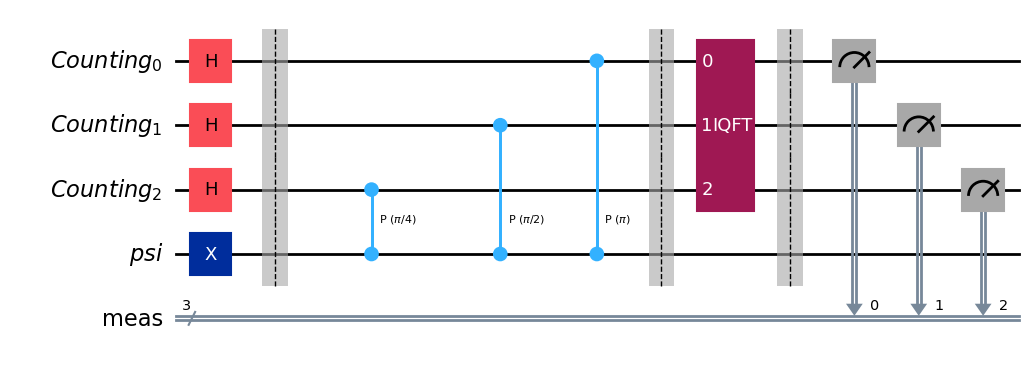

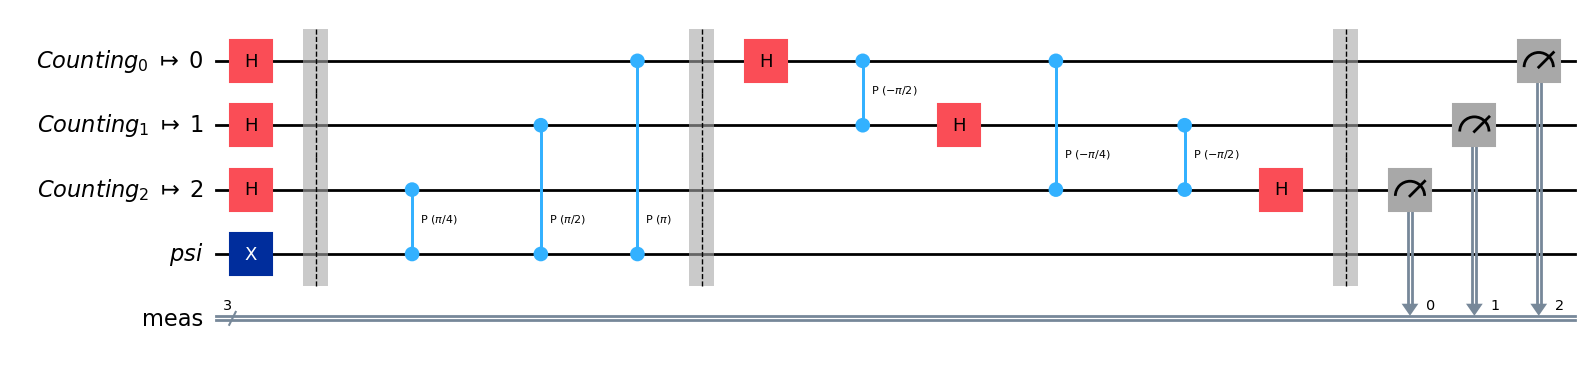

In [8]:
theta = np.pi / 4
U = PhaseGate(theta)
m = 3

psi_prep = QuantumCircuit(1)
psi_prep.x(0)  # prepares |1>, eigenstate of PhaseGate

qc = phase_estimation(U, psi_prep, m)

# Transpile
qc_transpiled = transpile(qc, backend)

display(qc.draw("mpl")) # Original circuit
display(qc_transpiled.draw("mpl"))  # Transpiled circuit

In [9]:
# Run
job = sampler.run([qc_transpiled], shots=1024)
counts = job.result()[0].data.meas.get_counts()

# Process results
most_likely_bitstring = max(counts, key=counts.get)
estimated_phase = int(most_likely_bitstring[::-1], 2) / 2**m # From binary to decimal

print(30 * "#")
print("Exact results:")
print(30 * "#")
print("Real phase:", theta/(2*np.pi))
print("\n")
print(30 * "#")
print("Algorithm's estimation")
print(30 * "#")
print("Counts:", counts)
print("Most likely bitstring:", most_likely_bitstring)
print("Estimated phase:", estimated_phase)

##############################
Exact results:
##############################
Real phase: 0.125


##############################
Algorithm's estimation
##############################
Counts: {'100': 1024}
Most likely bitstring: 100
Estimated phase: 0.125


We can now build random unitaries to see the algorithm performance.

In [10]:
def random_pea_instance(n_qubits: int, eigen_index: int = 0, seed: int = None):
    """
    Creates a random unitary gate U and an eigenstate preparation circuit
    for testing the Phase Estimation Algorithm.

    Parameters
    ----------
    n_qubits : int
        Number of qubits of the unitary operator U.
    eigen_index : int
        Index of the eigenvalue/eigenvector to use.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    U_gate : UnitaryGate
        Random unitary gate.
    psi_prep : QuantumCircuit
        Circuit that prepares an eigenstate of U.
    phase : float
        Theoretical phase associated with the selected eigenvalue.
    eigenvalue : complex
        Selected eigenvalue of U.
    """
    dim = 2 ** n_qubits

    # Build random unitary matrix
    U_matrix = random_unitary(dim, seed=seed)

    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(U_matrix)

    eigenvalue = eigenvalues[eigen_index]
    eigenvector = eigenvectors[:, eigen_index]

    # Convert eigenvalue into phase:
    # eigenvalue = exp(2*pi*i*phase)
    phase = np.angle(eigenvalue) / (2 * np.pi)
    phase = phase % 1

    # Convert matrix into a Qiskit gate
    U_gate = UnitaryGate(U_matrix, label="U")

    # Prepare the selected eigenstate
    psi_prep = QuantumCircuit(n_qubits)
    psi_prep.initialize(eigenvector, list(range(n_qubits)))

    return U_gate, psi_prep, phase, eigenvalue

Let's try for a given value of $m$.

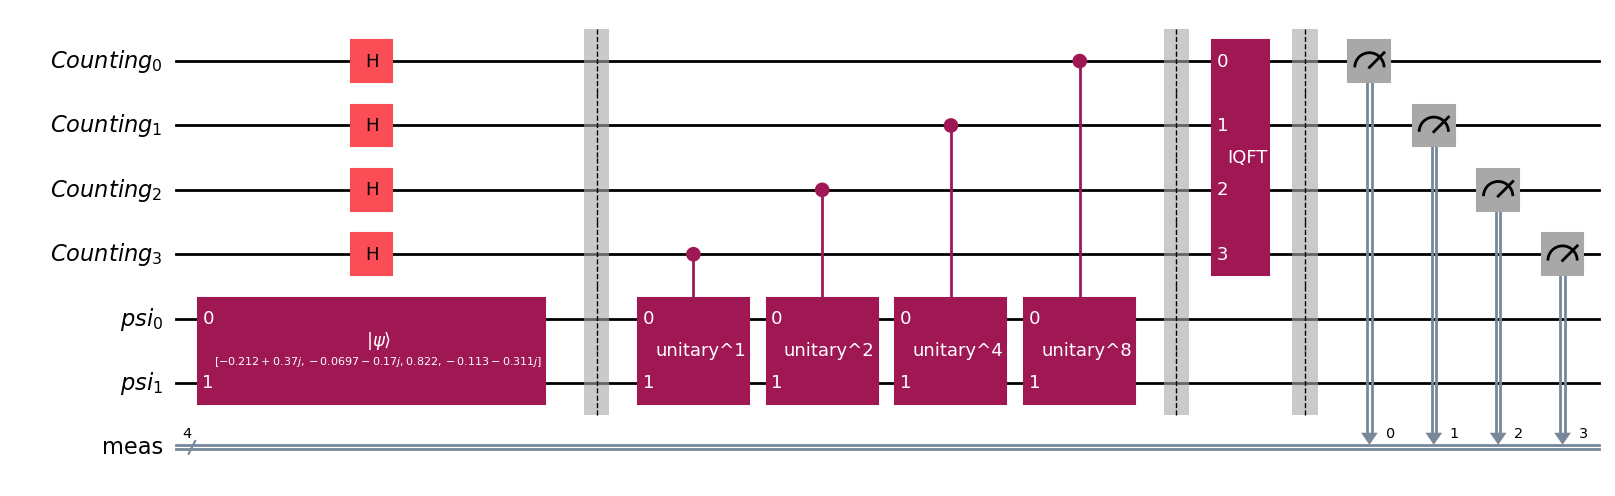

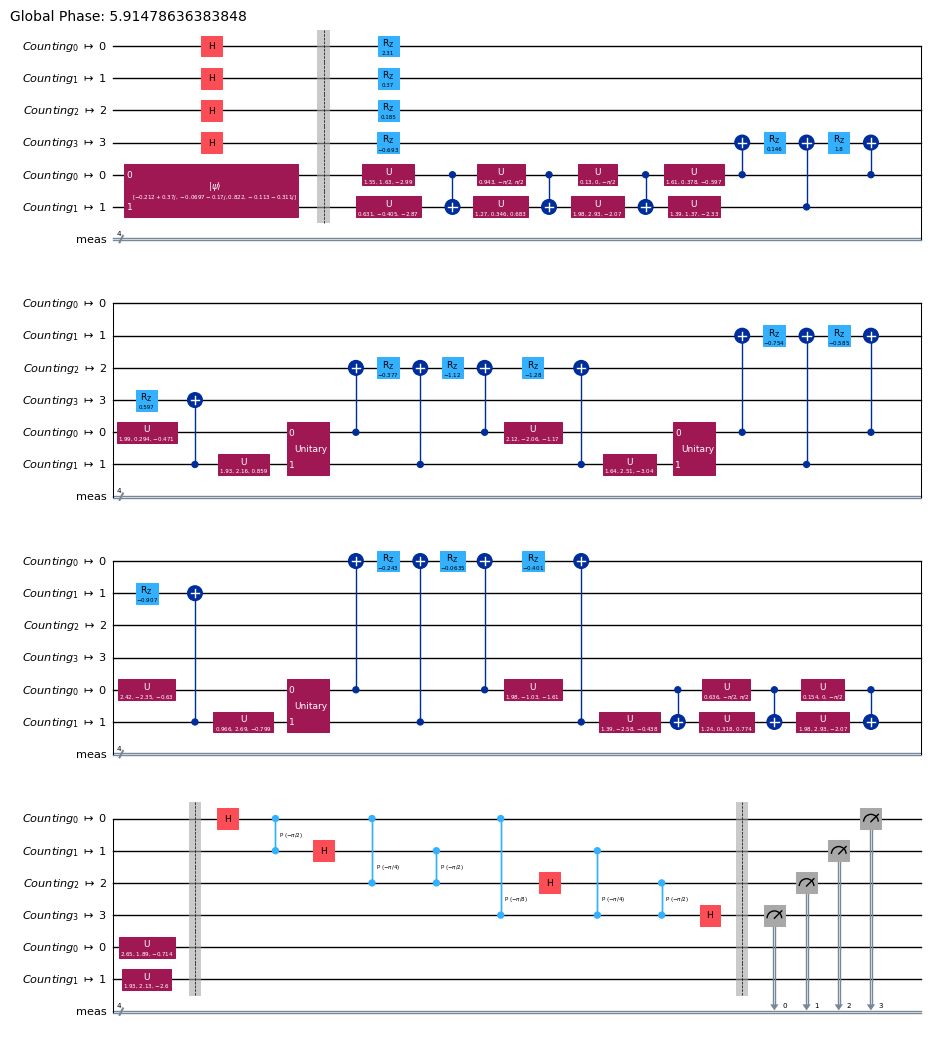

In [11]:
n_qubits = 2
m = 4

# Generate random instance
U, psi_prep, real_phase, eigenvalue = random_pea_instance(n_qubits=n_qubits, eigen_index=0, seed=SEED)

# Get the circuit
qc = phase_estimation(U, psi_prep, m)

# Transpile
qc_transpiled = transpile(qc, backend)

# Visualize the circuit
display(qc.draw("mpl"))
display(qc_transpiled.draw("mpl", scale=0.5))

In [12]:
# Run
job = sampler.run([qc_transpiled], shots=10000)
counts = job.result()[0].data.meas.get_counts()

# Process results
most_likely_bitstring = max(counts, key=counts.get)
estimated_phase = int(most_likely_bitstring[::-1], 2) / 2**m # From binary to decimal

print(30 * "#")
print("Exact results:")
print(30 * "#")
print("Eigenvalue:", eigenvalue)
print("Real phase:", real_phase)
print("\n")
print(30 * "#")
print("Algorithm's estimation")
print(30 * "#")
print("Counts:", counts)
print("Most likely bitstring:", most_likely_bitstring)
print("Estimated phase:", estimated_phase)


##############################
Exact results:
##############################
Eigenvalue: (-0.4517757719294934-0.8921315216365301j)
Real phase: 0.6753953532348699


##############################
Algorithm's estimation
##############################
Counts: {'0111': 38, '1101': 8803, '1000': 19, '0101': 511, '0011': 235, '1110': 31, '0110': 26, '1011': 85, '1001': 108, '1111': 20, '1100': 17, '0010': 9, '0001': 51, '1010': 18, '0100': 13, '0000': 16}
Most likely bitstring: 1101
Estimated phase: 0.6875


Finally, let's study how the precision changes as we increase the value of m.

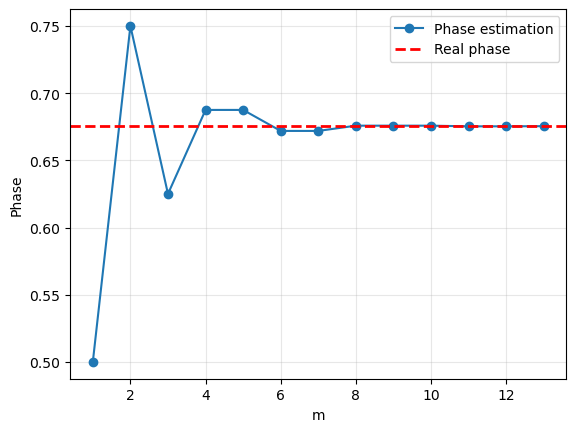

In [13]:
qc_list = []
m_max = 14
m_values = list(range(1, m_max))

for m in m_values:
    # Get the circuit
    qc = phase_estimation(U, psi_prep, m)

    # Transpile
    qc_transpiled = transpile(qc, backend)
    qc_list.append(qc_transpiled)

# Run
job = sampler.run(qc_list, shots=10000)

# Get results
estimated_phase_list = []
for i, m in enumerate(m_values):
    counts = job.result()[i].data.meas.get_counts()
    most_likely_bitstring = max(counts, key=counts.get)
    estimated_phase = int(most_likely_bitstring[::-1], 2) / 2**m # From binary to decimal
    estimated_phase_list.append(estimated_phase)

# Plot
plt.plot(list(range(1, m_max)), estimated_phase_list, marker="o", label="Phase estimation")
plt.axhline(y=real_phase, color='r', linestyle='--', linewidth=2, label='Real phase')
plt.xlabel("m")
plt.ylabel("Phase")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

The results show that increasing the number of counting qubits improves the theoretical precision of the Phase Estimation Algorithm. For each value of $m$, the phase can only be represented on a discrete binary grid with spacing $1/2^m$. Therefore, the algorithm does not return an arbitrary real number, but one of the values representable with $m$ bits.

As $m$ increases, this grid becomes finer, and the closest representable values get progressively closer to the real phase. This explains why the estimate may jump between nearby values for small $m$, but eventually stabilizes around the real phase.

However, this behavior assumes an ideal or simulated environment. On real quantum hardware, increasing $m$ also makes the circuit deeper and requires more controlled operations, which can introduce additional noise and gate errors. Therefore, in practice, there is a trade-off between increasing the theoretical precision of the estimation and maintaining a circuit that is reliable enough to run on real devices.